# About

This notebook provides examples demonstrating the application of the optical theorem to the Mie scattering problem for both plane and spherical incident waves.


# Optical Theorem for a Spherical Wave

First, we examine the optical theorem for an acoustic plane wave scattered by a sphere:
$$
\sigma_\text{ext}^\text{pw} = \frac{4\pi}{k}\text{Im}\left[\frac{p_\text{s}^\text{pw}(z)}{p_\text{b}^\text{pw}(z)}\right]z + \mathcal{O}\left(\frac{1}{k^3z}\right)
$$
To normalize the extinction cross section, we use the geometric cross section:
$$
\sigma_\text{geom} = \pi a^2
$$
where $a$ is the sphere radius.

We will investigate the convergence of the calculated quantity with respect to $z/a$.

In [9]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import Normalize

from mie_utils import p_n_PW, p_n_SW, a_n_sphere, line_p_s_generator

In [10]:
a = 1  # Sphere radius
c_host = 1  # Speed of sound in the host medium
rho_host = 1  # Density of the host medium
c_sphere = 0.3  # Speed of sound inside the sphere
rho_sphere = 1  # Density of the sphere

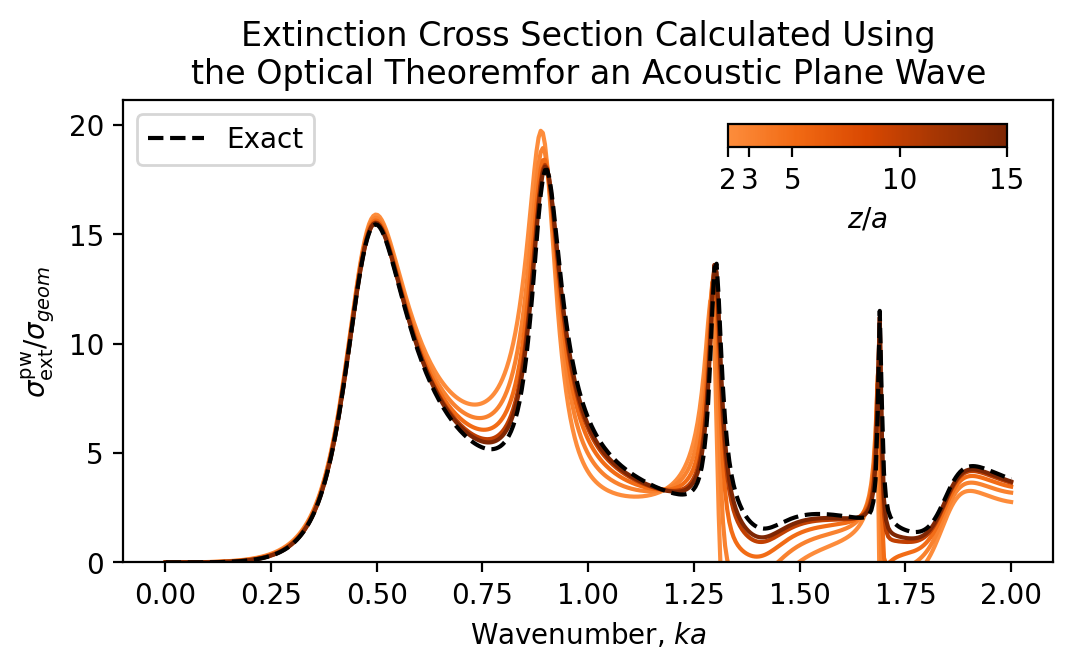

In [ ]:
plt.figure(figsize=(6, 3), dpi=200)

N = 60  # Maximum order of the expansion
k_list = np.linspace(0.001, 2, 400)  # Array of wavenumbers

sigma_geom = np.pi * a**2  # Geometric cross section

# Compute Mie coefficients and exact extinction cross section
a_n = a_n_sphere(N, k_list, a, c_host, rho_host, c_sphere, rho_sphere)
sigma_ext = -4 * np.pi / k_list**2 * np.real((2 * np.arange(N + 1) + 1.0) @ a_n)

# Plane wave expansion coefficients
p_n = p_n_PW(N)

z_list = [
    2 * a,
    3 * a,
    5 * a,
    10 * a,
    15 * a,
]  # z-coordinates for evaluating the optical theorem

# Color map
norm = Normalize(min(z_list), max(z_list))
cmap = LinearSegmentedColormap.from_list(
    "mycmap", plt.get_cmap("Oranges")(np.linspace(0.5, 1.0, 100))
)

# Compute extinction cross section using the optical theorem for different z values
for z in z_list:

    p_b = np.exp(1j * k_list * z)  # Incident plane wave
    p_s = np.sum(
        list(line_p_s_generator(k_list * z, p_n, a_n)), axis=0
    )  # Scattered field
    sigma_ext_pw = 4 * np.pi / k_list * np.imag(p_s / p_b) * z  # Optical theorem

    plt.plot(k_list * a, sigma_ext_pw / sigma_geom, color=cmap(norm(z)))

plt.plot(k_list * a, sigma_ext / sigma_geom, "--", label="Exact", color="black")

# Add colorbar for z/a values
new_axes = plt.gca().inset_axes((0.65, 0.90, 0.3, 0.05), transform=plt.gca().transAxes)
sm = ScalarMappable(norm=norm, cmap=cmap)
plt.colorbar(sm, new_axes, orientation="horizontal", ticks=z_list, label="$z/a$")

# ====== Style ======
plt.ylim(0)
plt.xlabel("Wavenumber, $ka$")
plt.legend(loc="upper left")
plt.ylabel("$\\sigma_\\text{ext}^\\text{pw}/\\sigma_{geom}$")
plt.title(
    "Extinction Cross Section Calculated Using\nthe Optical Theoremfor an Acoustic Plane Wave"
)
plt.show()

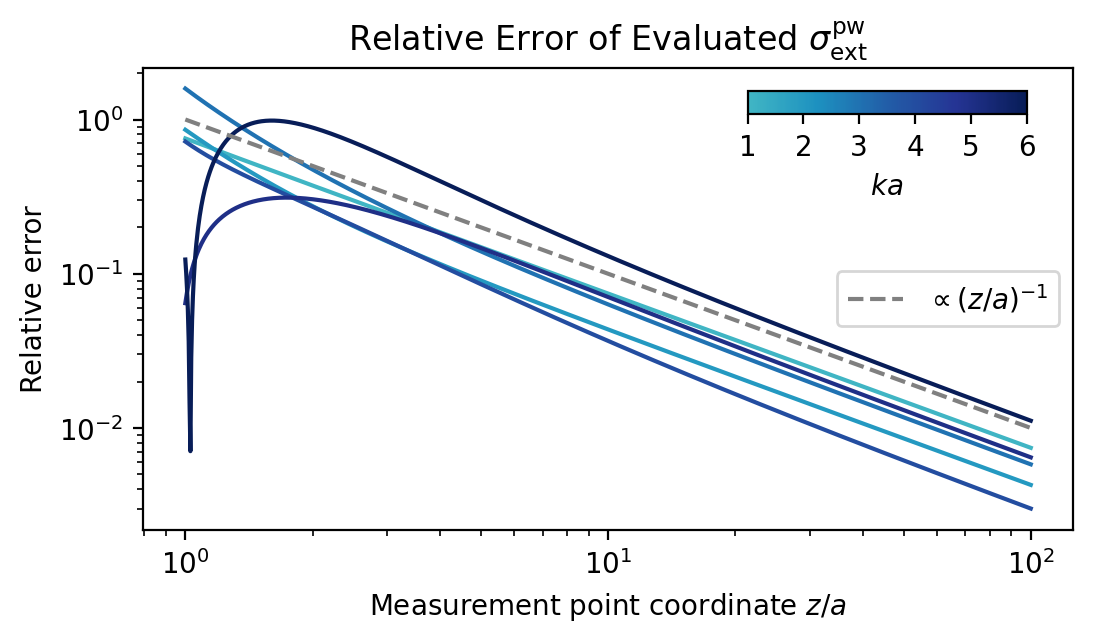

In [16]:
plt.figure(figsize=(6, 3), dpi=200)

N = 60  # Maximum order of the expansion
z_list = np.logspace(0, 2, 1000) * a  # Positions of measurement points along the z-axis
k_list = [1, 2, 3, 4, 5, 6]  # Array of wavenumbers

sigma_geom = np.pi * a**2  # Geometric cross section

# Color map
norm = Normalize(min(k_list), max(k_list))
cmap = LinearSegmentedColormap.from_list(
    "mycmap", plt.get_cmap("YlGnBu")(np.linspace(0.5, 1.0, 100))
)

for k in k_list:

    # Compute Mie coefficients and exact extinction cross section
    a_n = a_n_sphere(
        N, np.array(k), a, c_host, rho_host, c_sphere, rho_sphere
    )  # Mie coefficients
    sigma_ext = -4 * np.pi / k**2 * np.real((2 * np.arange(N + 1) + 1.0) @ a_n)

    # Incident and scattered fields
    p_b = np.exp(1j * k * z_list)  # Incident plane wave
    p_n = p_n_PW(N)  # Plane-wave expansion coefficients
    p_s = np.sum(
        list(line_p_s_generator(k * z_list, p_n, a_n)), axis=0
    )  # Scattered field

    sigma_ext_pw = 4 * np.pi * np.imag(p_s / p_b) / k * z_list  # Optical theorem

    relative_error = np.abs(sigma_ext_pw / sigma_ext - 1)
    plt.plot(z_list / a, relative_error, "-", color=cmap(norm(k)))

plt.plot(
    z_list / a, 1 / (z_list / a), "--", label="$\\propto (z/a)^{-1}$", color="gray"
)

# Add colorbar for ka values
new_axes = plt.gca().inset_axes((0.65, 0.90, 0.3, 0.05), transform=plt.gca().transAxes)
sm = ScalarMappable(norm=norm, cmap=cmap)
plt.colorbar(sm, new_axes, orientation="horizontal", ticks=k_list, label="$ka$")

# ====== Style ======
plt.title("Relative Error of Evaluated $\\sigma_{\\text{ext}}^{\\text{pw}}$")
plt.ylabel("Relative error")
plt.yscale("log")
plt.xscale("log")
plt.legend(loc="center right")
plt.xlabel("Measurement point coordinate $z/a$")
plt.show()

As predicted, the error in the extinction cross section obtained via the optical theorem decreases proportionally to $(z/a)^{-1}$.

# Optical Theorem for a Spherical Wave

In the case of a spherical incident wave, when the extinction cross section is evaluated analogously to the plane wave case, the optical theorem takes the form:
$$
\sigma_\text{ext}^\text{sw} = \frac{4\pi}{k}\text{Im}\left[\frac{p_\text{s}^\text{sw}(z)}{p_\text{b}^\text{sw}(z)}\right]\frac{zR}{z+R} + \mathcal{O}\left(\frac{1}{k^3z}\right) + \mathcal{O}\left(\frac{1}{k^3R}\right)
$$
where $R$ is the distance between the source and the center of the sphere.


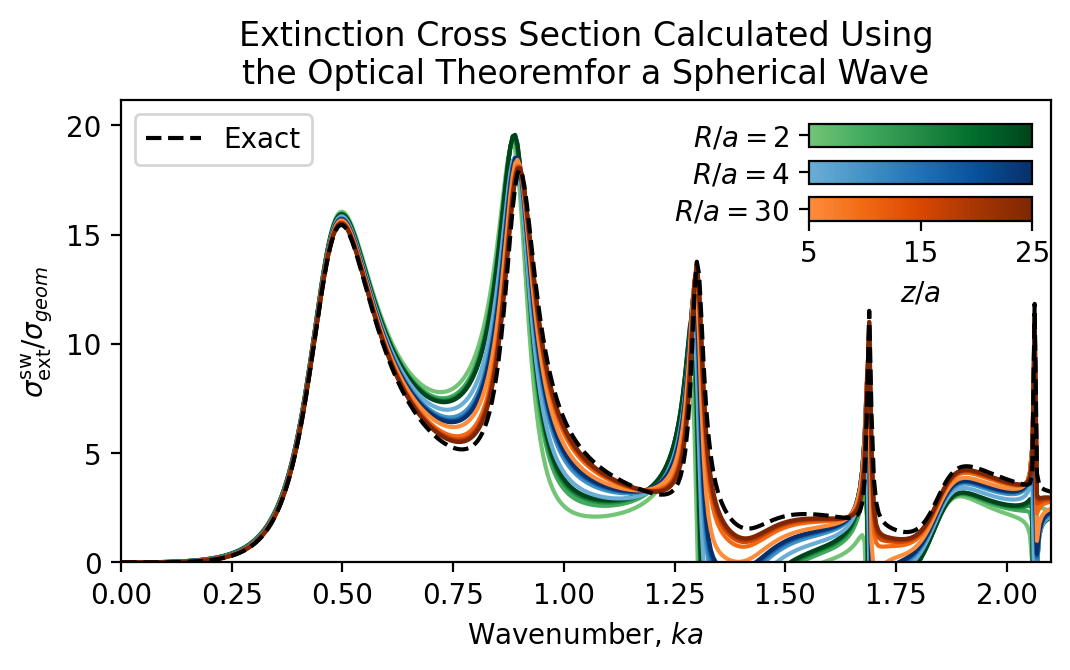

In [20]:
plt.figure(figsize=(6, 3), dpi=200)

N = 60  # Maximum order of expansion
k_list = np.linspace(0.001, 2.1, 400)  # Array of wavenumbers
R_list = [2 * a, 4 * a, 30 * a]  # Distances between source and sphere center

sigma_geom = np.pi * a**2  # Geometric cross section


# Compute Mie coefficients and exact extinction cross section
a_n = a_n_sphere(N, k_list, a, c_host, rho_host, c_sphere, rho_sphere)
sigma_ext = -4 * np.pi / k_list**2 * np.real((2 * np.arange(N + 1) + 1.0) @ a_n)

# Define color maps for each R/a
cmaps = (
    LinearSegmentedColormap.from_list(
        "mycmap", plt.get_cmap("Greens")(np.linspace(0.5, 1.0, 100))
    ),
    LinearSegmentedColormap.from_list(
        "mycmap", plt.get_cmap("Blues")(np.linspace(0.5, 1.0, 100))
    ),
    LinearSegmentedColormap.from_list(
        "mycmap", plt.get_cmap("Oranges")(np.linspace(0.5, 1.0, 100))
    ),
)

for i, (R_a, cmap) in enumerate(zip(R_list, cmaps)):
    # Spherical wave expansion coefficients
    p_n = np.array([p_n_SW(N, k_, R_a / a) for k_ in k_list]).T

    z_list = (
        np.arange(5, 30, 5, dtype=float) * a
    )  # z-coordinates for evaluating the optical theorem
    norm = Normalize(min(z_list), max(z_list))

    for z in z_list:

        p_b = R_a * np.exp(1j * k_list * z) / (z + R_a)  # Incident spherical wave
        p_s = np.sum(
            list(line_p_s_generator(k_list * z, p_n, a_n)), axis=0
        )  # Scattered field
        sigma_ext_pw = (
            4 * np.pi / k_list * np.imag(p_s / p_b) * z * R_a / (z + R_a)
        )  # Optical theorem

        plt.plot(k_list * a, sigma_ext_pw / sigma_geom, color=cmap(norm(z)))

    # Add colorbar for z/a values
    new_axes = plt.gca().inset_axes(
        (0.74, 0.90 - 0.08 * i, 0.24, 0.05), transform=plt.gca().transAxes
    )
    sm = ScalarMappable(norm=norm, cmap=cmap)
    if i != len(R_list) - 1:
        plt.colorbar(sm, new_axes, orientation="horizontal")
        new_axes.set_xticks([])
    else:
        plt.colorbar(
            sm,
            new_axes,
            orientation="horizontal",
            ticks=z_list[[0, len(z_list) // 2, -1]] / a,
            label="$z/a$",
        )
    new_axes.set_yticks([0.5], labels=[f"$R/a={R_a}$"])

plt.plot(k_list * a, sigma_ext / sigma_geom, "--", label="Exact", color="black")

# ====== Style ======
plt.ylim(0)
plt.xlabel("Wavenumber, $ka$")
plt.ylabel("$\\sigma_\\text{ext}^\\text{sw}/\\sigma_{geom}$")
plt.legend(loc="upper left")
plt.xlim(0, 2.1)
plt.title(
    "Extinction Cross Section Calculated Using\nthe Optical Theoremfor a Spherical Wave"
)
plt.show()

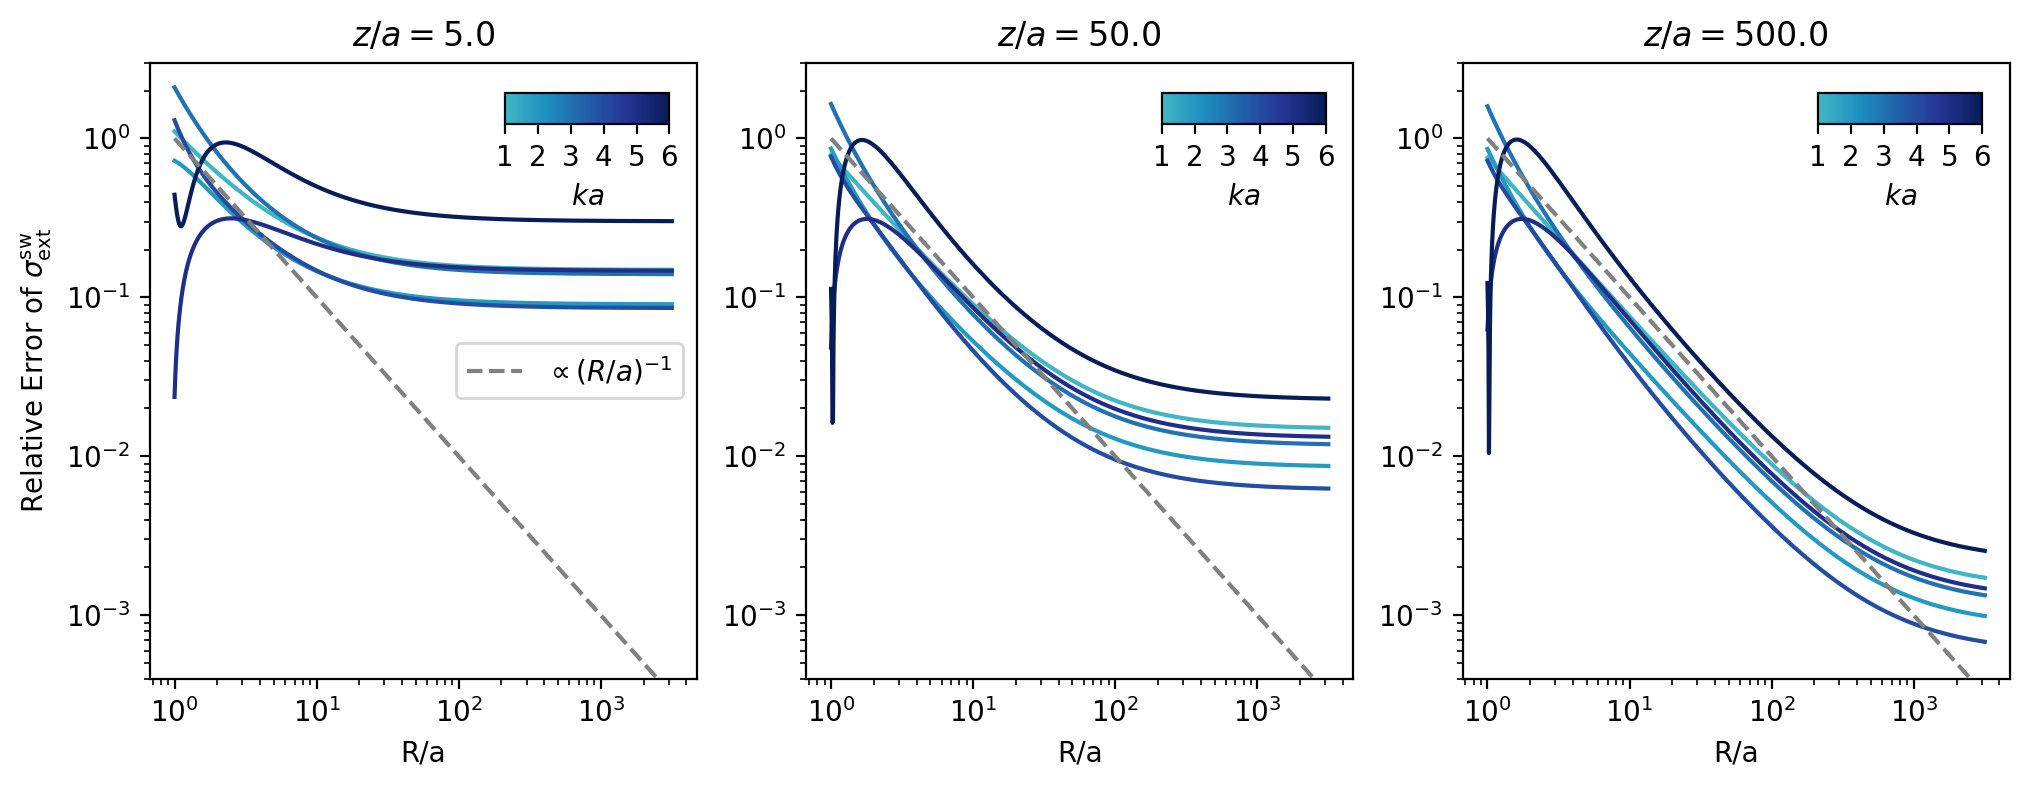

In [23]:
plt.figure(figsize=(12, 4), dpi=200)

N = 60  # Maximum order of expansion
k_list = [1, 2, 3, 4, 5, 6]  # Wavenumber array
R_list = np.logspace(0, 3.5, 1000) * a  # Distance between source and sphere center

sigma_geom = np.pi * a**2  # Geometric cross section

# Colormap for different ka values
norm = Normalize(min(k_list), max(k_list))
cmap = LinearSegmentedColormap.from_list(
    "mycmap", plt.get_cmap("YlGnBu")(np.linspace(0.5, 1.0, 100))
)

for i, z in enumerate([5 * a, 50 * a, 500 * a]):
    plt.subplot(1, 3, i + 1)
    for k in k_list:

        a_n = a_n_sphere(
            N, np.array(k), a, c_host, rho_host, c_sphere, rho_sphere
        )  # Mie coefficients
        p_b = R_list * np.exp(1j * k * z) / (z + R_list)  # Incident wave

        p_n = np.array(
            [p_n_SW(N, k, R_) for R_ in R_list]
        ).T  # Plane wave expansion coefficients
        p_s = np.sum(
            list(line_p_s_generator(np.array(k * z), p_n, a_n)), axis=0
        )  # Scattered wave

        sigma_ext_sw = (
            4 * np.pi / k * np.imag(p_s / p_b) * (z * R_list) / (z + R_list)
        )  # Optical theorem
        sigma_ext = (
            -4 * np.pi / k**2 * np.real((2 * np.arange(N + 1) + 1.0) @ a_n)
        )  # Exact extinction cross section

        relative_error = np.abs(sigma_ext_sw / sigma_ext - 1)
        plt.plot(R_list, relative_error, "-", color=cmap(norm(k)))

    plt.plot(
        R_list / a, 1 / (R_list / a), "--", label="$\\propto (R/a)^{-1}$", color="gray"
    )

    # Add colorbar
    new_axes = plt.gca().inset_axes(
        (0.65, 0.90, 0.3, 0.05), transform=plt.gca().transAxes
    )
    sm = ScalarMappable(norm=norm, cmap=cmap)
    plt.colorbar(sm, new_axes, orientation="horizontal", ticks=k_list, label="$ka$")

    # ====== Style ======
    if i == 0:
        plt.ylabel("Relative Error of $\\sigma_{\\text{ext}}^{\\text{sw}}$")
        plt.legend(loc="center right")
    plt.yscale("log")
    plt.xscale("log")
    plt.xlabel("R/a")
    plt.ylim(4e-4, 3)
    plt.title(f"$z/a = {z/a}$")

plt.show()

As predicted, the error in the extinction cross section obtained via the optical theorem decreases proportionally not only to 
$a/z$ but also to $a/R$.

In [24]:
N = 60  # Maximum order of expansion
k_list = [1, 1.5, 2]  # Wavenumber array

z = a * (
    1 / np.linspace(0.1, 0.0001, 240)
)  # Positions of measurement points along the z-axis
R_list = a * (
    1 / np.linspace(0.1, 0.0001, 250)
)  # Distance between source and sphere center

errors = []
for k in k_list:

    a_n = a_n_sphere(
        N, np.array(k), a, c_host, rho_host, c_sphere, rho_sphere
    )  # Mie coefficients
    sigma_ext = (
        -4 * np.pi / k**2 * np.real((2 * np.arange(N + 1) + 1.0) @ a_n)
    )  # Exact extinction cross section

    sigmas = []
    for R in R_list:
        p_b = R * np.exp(1j * k * z) / (z + R)  # Incident wave

        p_n = p_n_SW(N, k, R)  # Plane wave expansion coefficients
        p_s = np.sum(
            list(line_p_s_generator(k * z, p_n, a_n)), axis=0
        )  # Scattered wave

        sigma_ext_sw = (
            4 * np.pi / k * np.imag(p_s / p_b) * (z * R) / (z + R)
        )  # Optical theorem

        sigmas.append(sigma_ext_sw)

    relative_error = np.abs(np.array(sigmas) / sigma_ext - 1)
    errors.append(relative_error)

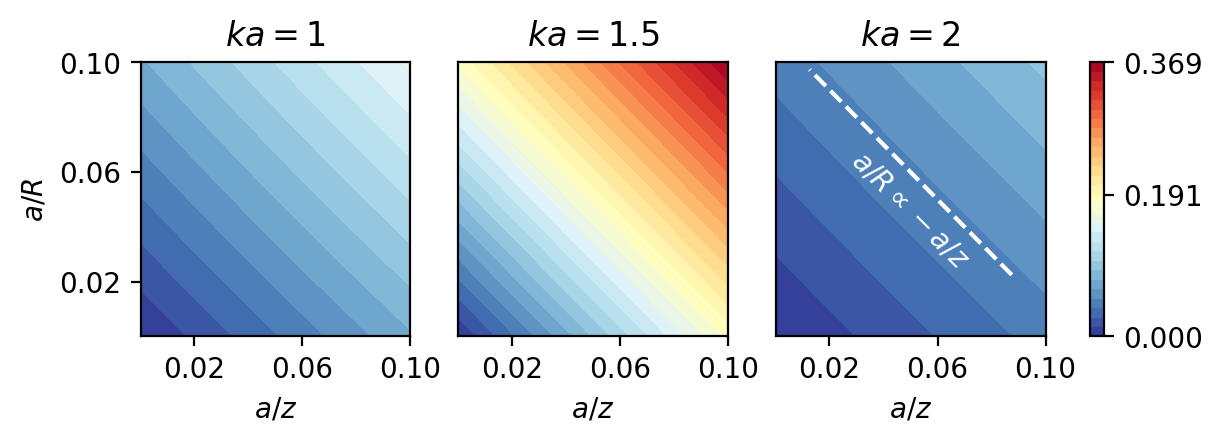

In [25]:
levels = np.linspace(np.min(errors), np.max(errors), 30)

fig, axes = plt.subplots(
    1, len(k_list), figsize=(6, 2.1), layout="constrained", dpi=200
)

for i, k in enumerate(k_list):
    plt.subplot(1, len(k_list), i + 1)
    plt.contourf(1 / z, 1 / R_list, errors[i], levels=levels, cmap="RdYlBu_r")

    plt.xticks([0.02, 0.06, 0.1])
    plt.yticks([0.02, 0.06, 0.1])

    if i != 0:
        plt.yticks([])
    else:
        plt.ylabel("$a/R$")
    if i == len(k_list) - 1:
        cbar = plt.colorbar()
        cbar.set_ticks([levels[0], levels[len(levels) // 2], levels[-1]])

        _z = z[30:-30]
        plt.plot(
            1 / _z,
            0.11 - 1 / _z,
            color="white",
            linestyle="--",
            label="$C = a/R + a/z$",
        )
        plt.text(0.026, 0.025, "$a/R \\propto - a/z$", color="white", rotation=-45)
    plt.xlabel("$a/z$")

    plt.title(f"$ka = {k * a}$")
plt.show()

This analysis shows that, for various wavenumbers $ka$, the relative error of the optical theorem scales with $a/R$ and $a/z$.
The dependence on $ka$, however, is not that simple and related to the particle’s scattering characteristics.